In [1]:
import pandas as pd 

In [6]:
df = pd.read_csv("../data/raw/Student Social Media And Mental Health Impact.csv")


In [2]:
df_train = pd.read_csv('../data/processed/train_limpio.csv')
df_test = pd.read_csv('../data/processed/test_limpio.csv')


## Paso 6: Construcción y optimización del modelo 

In [3]:
X_train = df_train.drop(columns='Stress_Level')
X_test = df_test.drop(columns='Stress_Level')
y_train = df_train['Stress_Level']
y_test = df_test['Stress_Level']

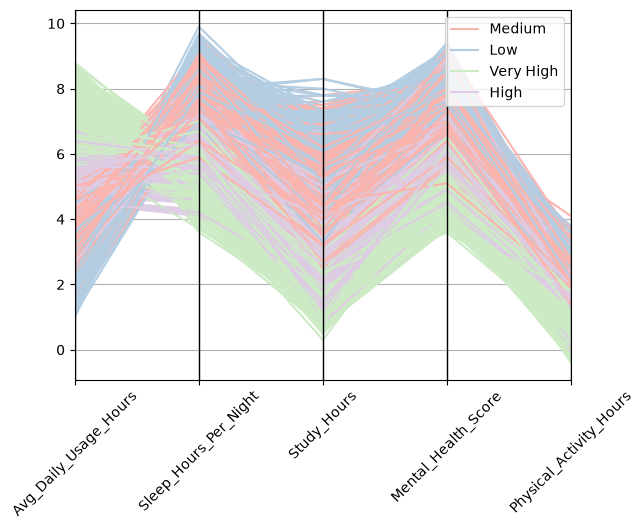

In [37]:
import pandas as pd

X = df[[
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Study_Hours",
    "Mental_Health_Score",
    "Physical_Activity_Hours"
]]

y = df["Stress_Level"]


pd.plotting.parallel_coordinates(
    X.assign(Stress_Level=y), "Stress_Level", color=["#FBB4AE", "#B3CDE3", "#CCEBC5", "#DECBE4"]).tick_params(axis='x', rotation=45)

Como habíamos mencionado en el EDA, debido a la alta multicolinealidad entre nuestras variables, vamos a utilizar modelos relacionados a Árboles y probaremos tres de ellos: Árbol de Decisión, Random Forest y XGBoost. Iremos desarrollando uno a uno a continuación.


### Árbol de Decisión:

**Inicialización y entrenamiento del modelo**

In [39]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

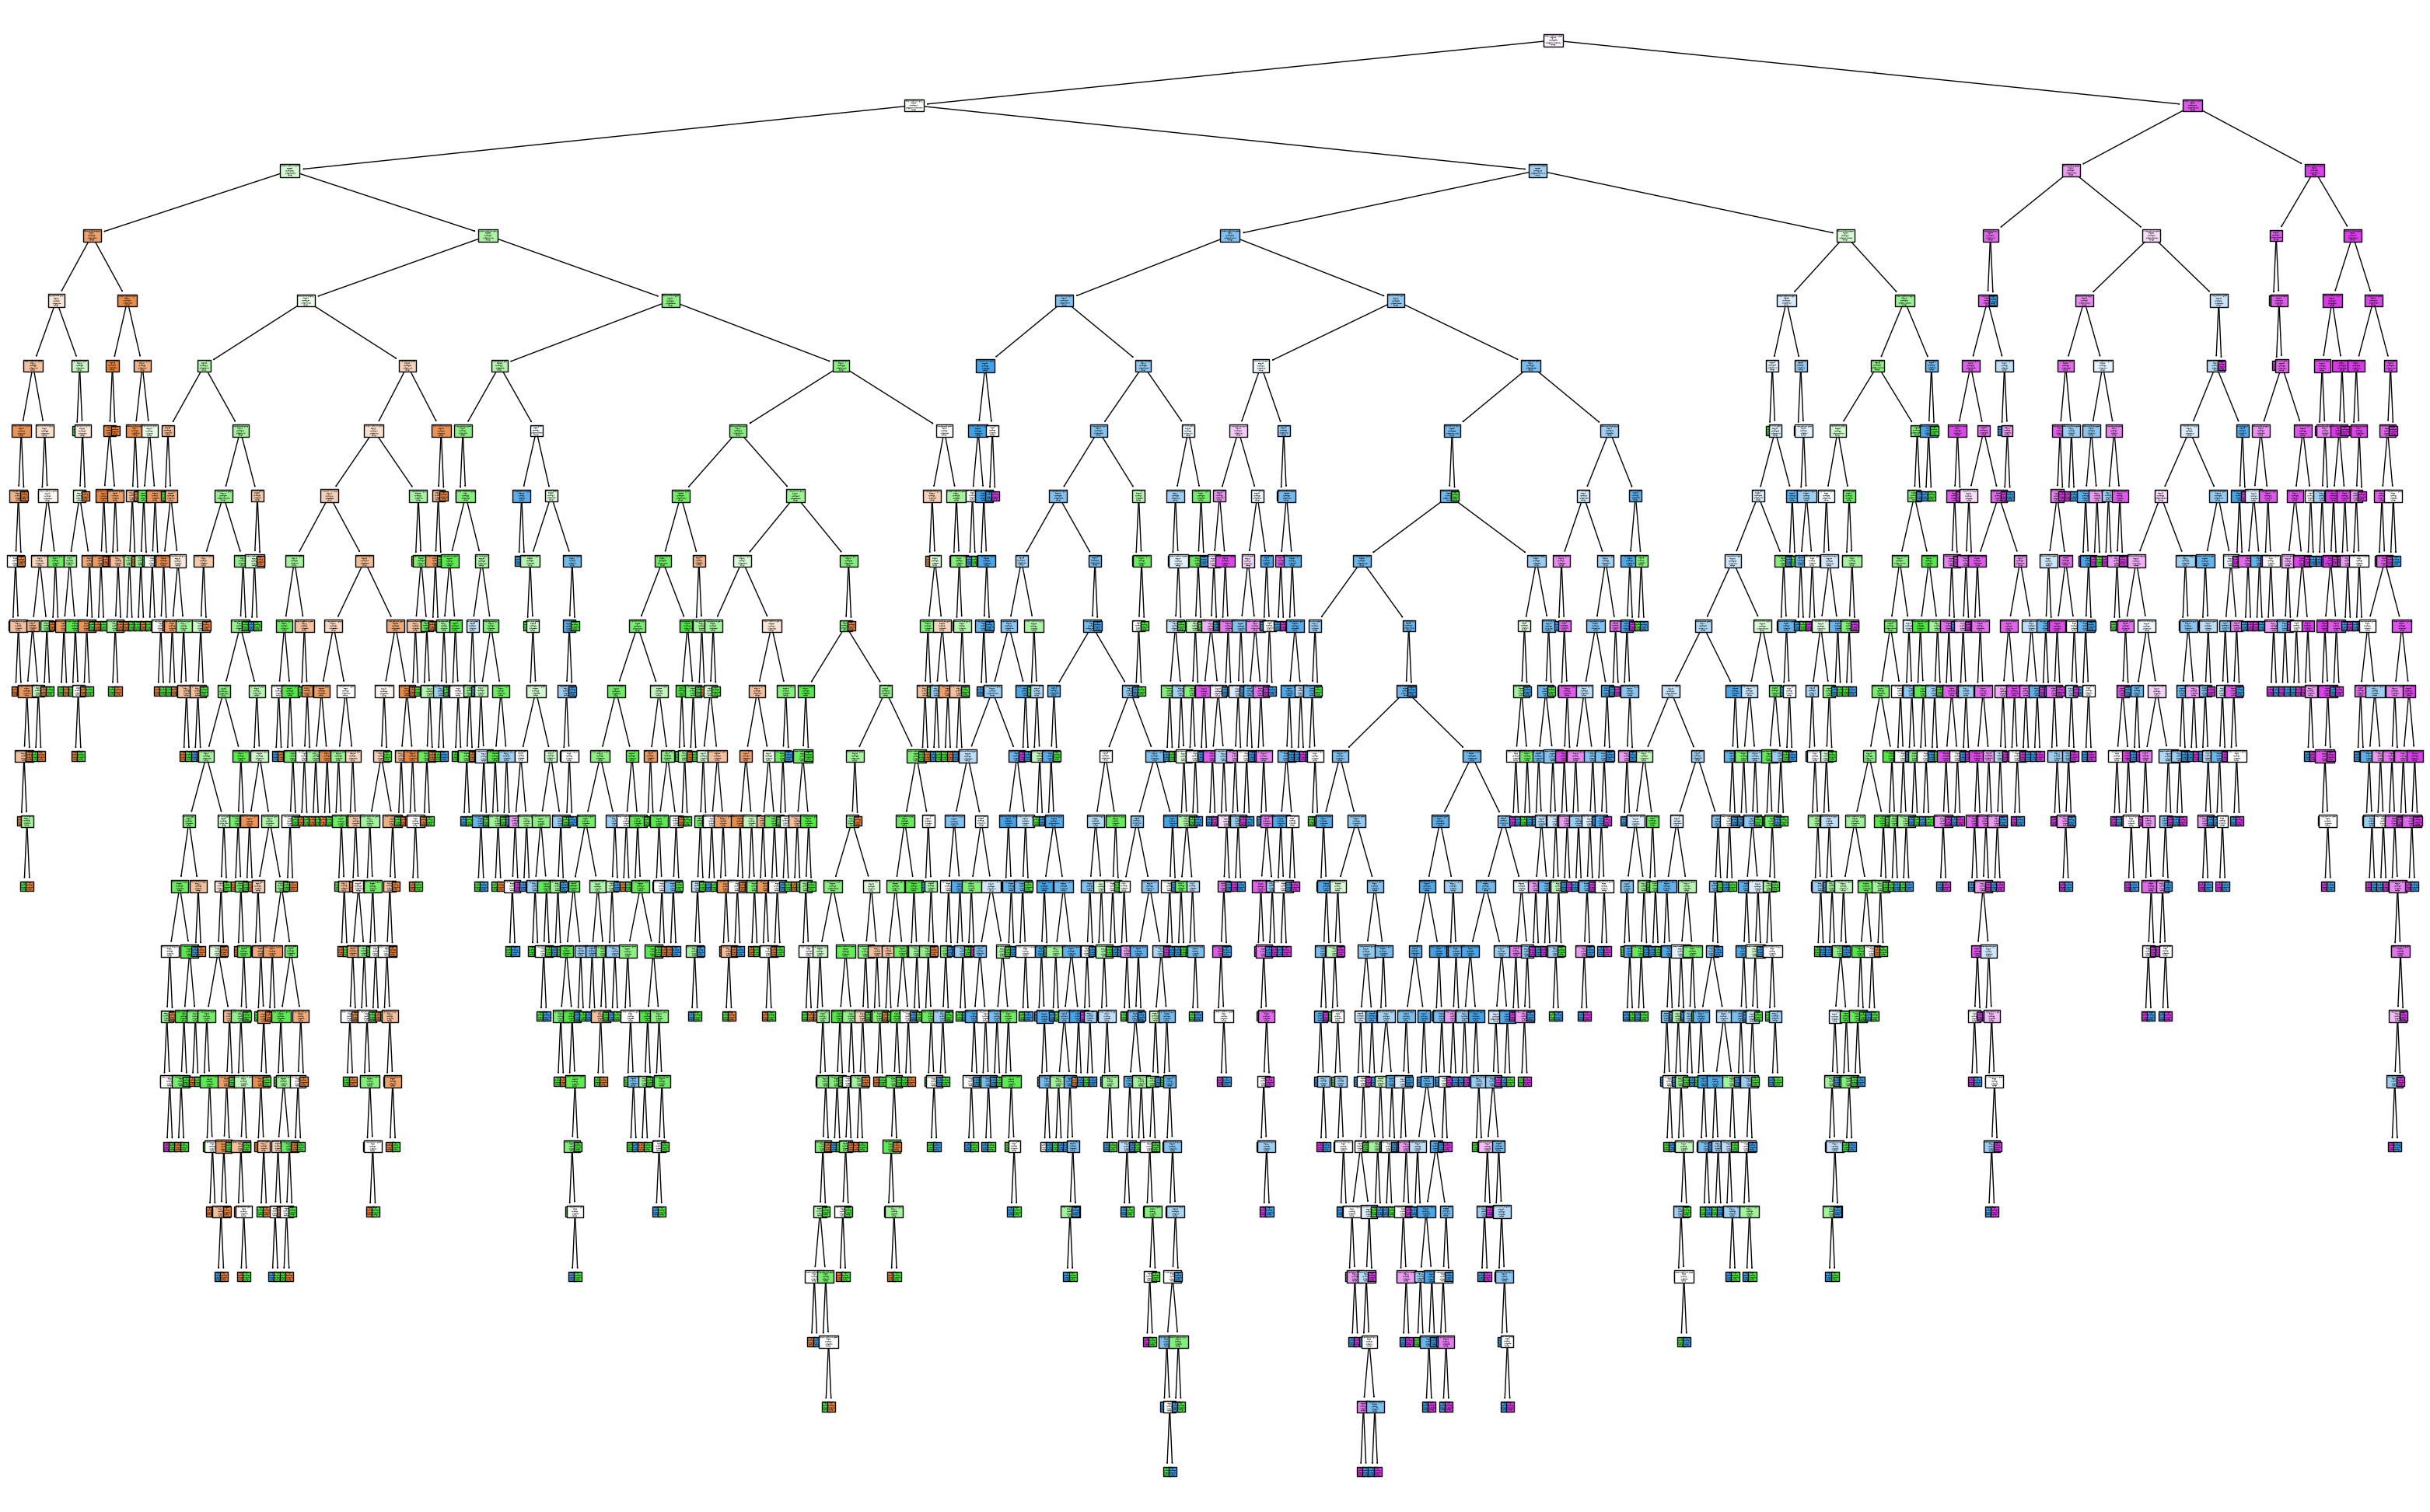

In [43]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(40,25))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True)

plt.show()

Debido a que nuestro árbol es extremadamente grande/profundo con demasiadas ramas para visibilizarlas todas en detalle, vamos a limitar la profundidad para presentarlo de forma más clara, mostrando sólo los primeros 3 niveles del árbol, que son los más importantes para interpretar qué variables utiliza primero para clasificar 'Stress_Level'.

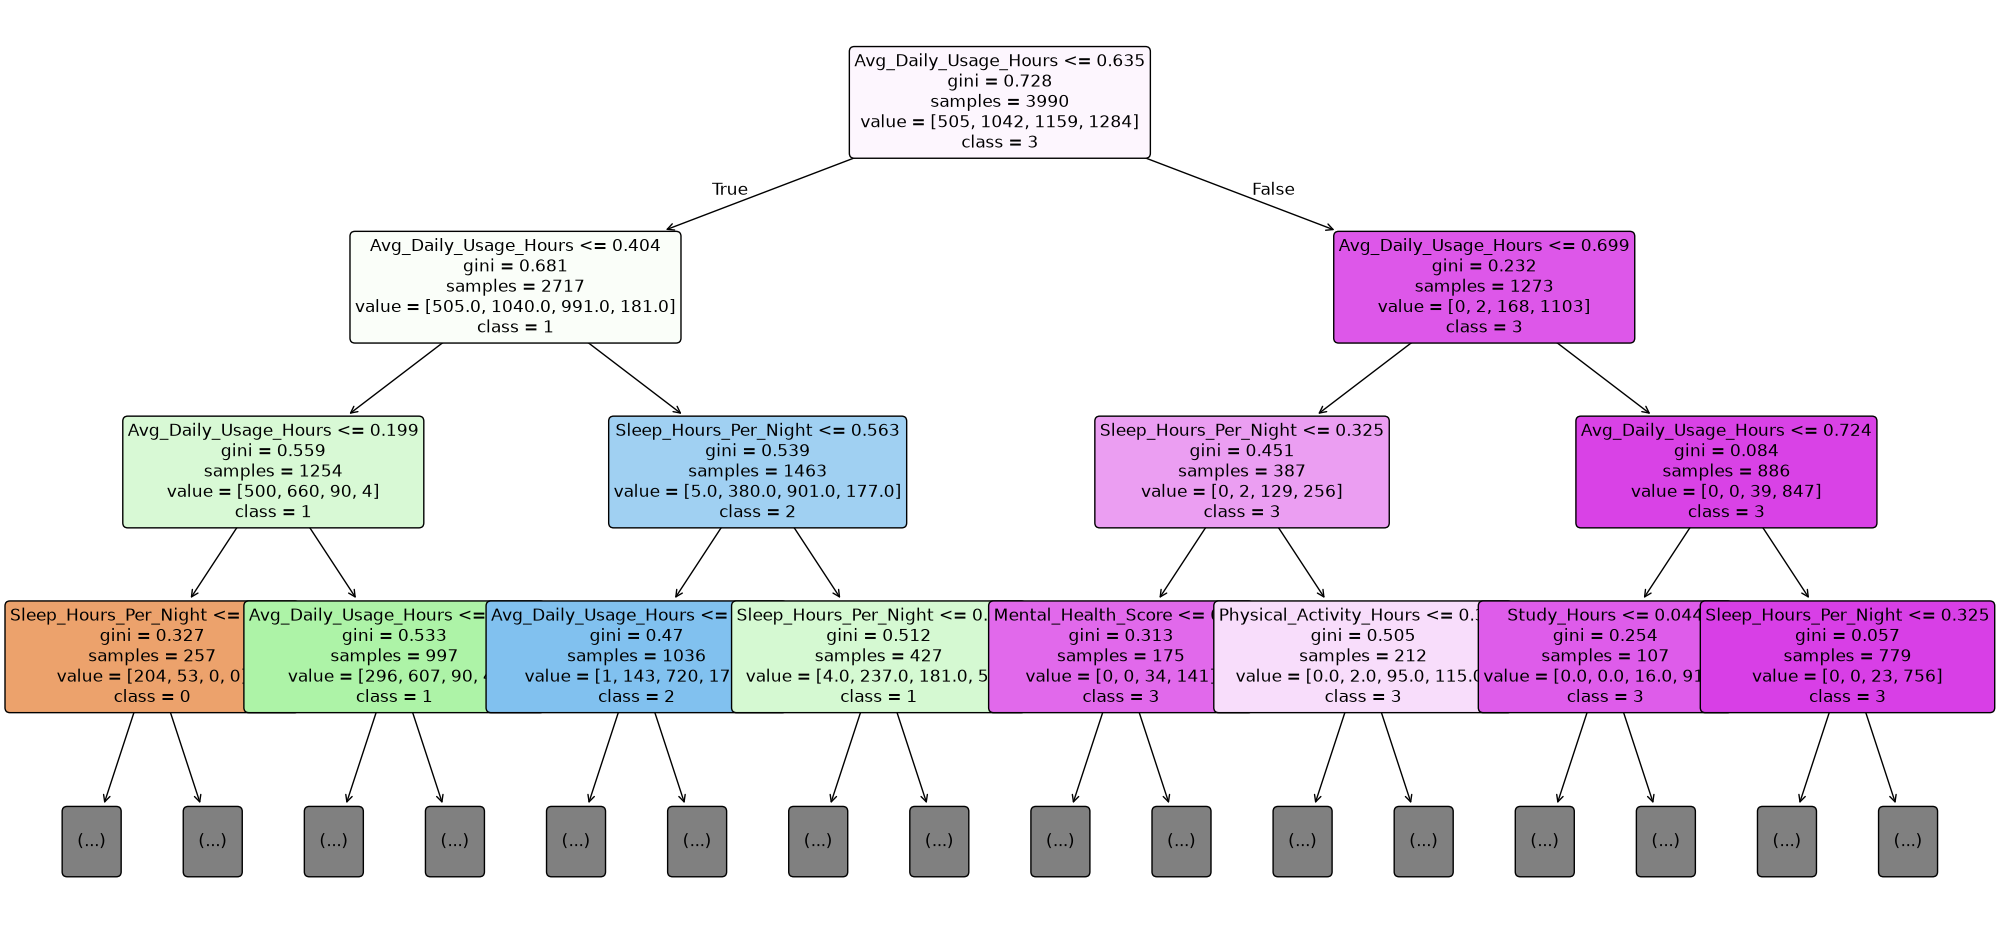

In [52]:

fig = plt.figure(figsize=(25, 12))

tree.plot_tree(model, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True,rounded=True, max_depth=3, fontsize=12)

plt.show()



**Predicción del Modelo:**

In [53]:
y_pred = model.predict(X_test)
y_pred

array([3, 3, 2, 2, 3, 2, 2, 1, 0, 1, 3, 2, 0, 3, 2, 0, 0, 3, 3, 3, 1, 1,
       2, 2, 2, 3, 2, 3, 2, 1, 2, 1, 3, 2, 3, 0, 3, 1, 1, 3, 1, 1, 3, 2,
       1, 1, 2, 2, 3, 3, 1, 3, 2, 1, 1, 1, 0, 3, 3, 2, 3, 0, 3, 2, 1, 3,
       3, 0, 2, 1, 2, 2, 3, 2, 3, 3, 2, 0, 2, 1, 3, 2, 2, 3, 2, 2, 3, 3,
       3, 2, 3, 2, 2, 3, 2, 1, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 1, 1, 1,
       3, 1, 3, 0, 2, 1, 1, 2, 1, 2, 2, 2, 0, 3, 2, 2, 3, 1, 0, 2, 0, 2,
       1, 0, 0, 2, 3, 1, 3, 0, 2, 1, 3, 0, 3, 2, 1, 2, 2, 3, 2, 3, 2, 3,
       3, 2, 3, 2, 0, 2, 3, 0, 2, 2, 2, 0, 1, 1, 3, 1, 0, 1, 3, 3, 0, 0,
       1, 0, 1, 3, 3, 3, 3, 0, 1, 3, 2, 0, 0, 0, 1, 2, 3, 3, 0, 1, 2, 1,
       2, 3, 1, 3, 3, 1, 2, 3, 3, 2, 1, 0, 1, 0, 3, 0, 3, 1, 2, 0, 2, 2,
       0, 2, 3, 3, 2, 1, 1, 1, 3, 3, 3, 0, 3, 1, 3, 1, 3, 1, 1, 1, 0, 3,
       0, 0, 3, 1, 3, 3, 3, 1, 2, 0, 3, 2, 1, 2, 2, 1, 3, 2, 0, 1, 1, 0,
       2, 3, 2, 2, 2, 2, 0, 3, 0, 1, 1, 3, 2, 3, 1, 3, 1, 1, 2, 3, 1, 3,
       3, 3, 3, 0, 3, 0, 0, 1, 3, 3, 3, 3, 1, 2, 0,

In [54]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7084168336673347

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Modelo base
arbol = DecisionTreeClassifier(random_state=42)

# Hiperparámetros a probar
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

# Búsqueda de la mejor combinación
grid_search = GridSearchCV(
    estimator=arbol,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("\nMejor Accuracy en Cross-Validation:")
print(grid_search.best_score_)

Mejores hiperparámetros:
{'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor Accuracy en Cross-Validation:
0.7368421052631579
